In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.drop(['customerID'],axis=1)
df['Churn']=df['Churn'].apply(lambda x:1 if x=='Yes' else 0)
df.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3960,Female,0,No,No,3,Yes,No,DSL,No,No,Yes,No,Yes,No,Month-to-month,No,Electronic check,57.55,161.45,0
1809,Male,1,Yes,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.00,2642.05,1
3533,Female,0,No,No,10,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.80,198.25,0
4859,Male,1,Yes,No,63,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Credit card (automatic),108.50,6991.90,0
4578,Female,0,No,No,10,Yes,No,DSL,No,No,No,Yes,No,Yes,Month-to-month,Yes,Mailed check,60.95,629.55,0
2887,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.05,45.05,1
2225,Male,0,No,No,33,No,No phone service,DSL,No,Yes,No,No,Yes,No,One year,Yes,Electronic check,39.10,1309.00,0
2730,Male,0,No,No,49,Yes,Yes,Fiber optic,No,Yes,No,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),106.65,5168.10,0
2395,Female,1,Yes,No,31,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,No,One year,Yes,Electronic check,90.70,2835.50,0
2234,Male,0,Yes,Yes,23,Yes,Yes,DSL,No,Yes,No,Yes,No,No,Two year,No,Mailed check,59.70,1414.20,0


In [92]:
df_final=pd.get_dummies(df,drop_first=True)
df_final.sample(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4510,0,38,68.15,2656.30,0,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
1892,1,4,50.95,207.35,0,True,False,False,False,True,...,False,True,False,True,False,False,True,True,False,False
170,0,43,84.25,3539.25,0,True,True,False,True,False,...,False,False,False,False,True,False,True,False,False,False
3710,0,10,20.45,242.40,0,True,True,True,True,False,...,True,False,True,False,True,False,False,False,False,True
5140,0,1,89.25,89.25,0,True,False,False,True,False,...,False,True,False,True,False,False,True,False,True,False
2943,0,40,24.60,973.95,0,True,False,False,True,False,...,True,False,True,False,False,True,True,False,False,True
4266,0,62,102.00,6529.25,1,True,False,False,True,False,...,False,False,False,True,True,False,False,False,True,False
5004,0,64,111.15,6953.40,0,False,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
6110,0,19,59.80,1130.85,0,False,True,False,True,False,...,False,False,False,True,False,False,True,False,False,True
2446,0,18,90.00,1527.35,1,False,False,False,True,False,...,False,True,False,False,False,False,True,True,False,False


In [73]:
print(df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [74]:
print(df.shape)

(7043, 20)


In [75]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [76]:
print(df['gender'].value_counts())

gender_churn = df.groupby(['gender', 'Churn']).size().unstack()

gender
Male      3555
Female    3488
Name: count, dtype: int64


In [77]:
print(gender_churn)

Churn      0    1
gender           
Female  2549  939
Male    2625  930


In [78]:
# It converts the `TotalCharges` column to numeric values and replaces any invalid or non-numeric entries with `NaN`.


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

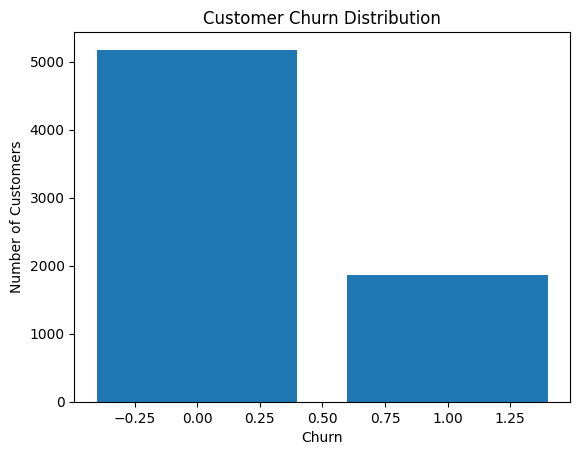

In [79]:
# How many customers churned and did not churn


churn_count = df['Churn'].value_counts()

plt.figure()
plt.bar(churn_count.index, churn_count.values)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

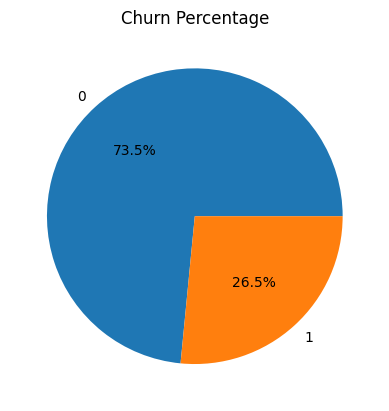

In [80]:
# Calculates the percentage of churned vs non-churned customers

churn_count = df['Churn'].value_counts()

plt.figure()
plt.pie(churn_count.values, labels=churn_count.index, autopct='%1.1f%%')
plt.title("Churn Percentage")
plt.show()

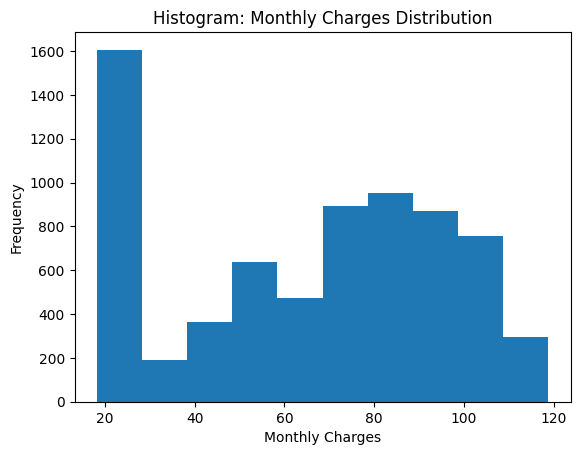

In [81]:
# Histogram to show how monthly charges are distributed and how frequently each charge range occurs.

plt.figure()
plt.hist(df['MonthlyCharges'])
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.title("Histogram: Monthly Charges Distribution")
plt.show()

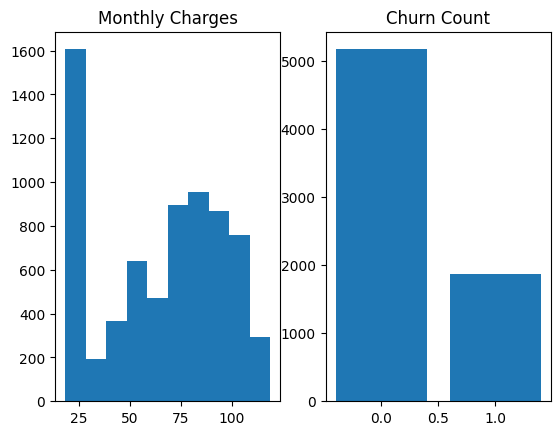

In [82]:
# A single figure with two subplots—one showing the distribution of monthly charges and the other showing the count of churned vs non-churned customers.

churn_count = df['Churn'].value_counts()

plt.figure()

plt.subplot(1, 2, 1)
plt.hist(df['MonthlyCharges'])
plt.title("Monthly Charges")

plt.subplot(1, 2, 2)
plt.bar(churn_count.index, churn_count.values)
plt.title("Churn Count")

plt.show()

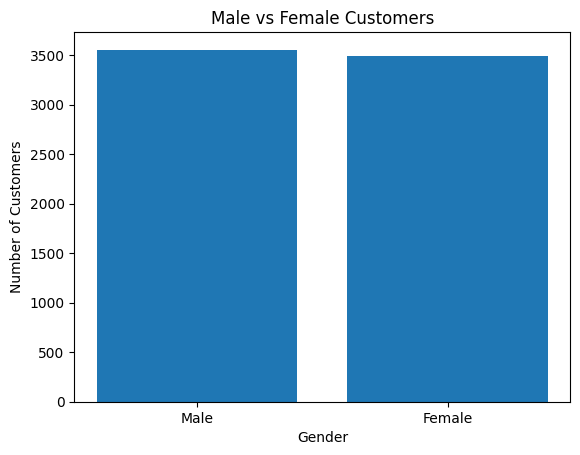

In [83]:
# Counts male and female customers and displays their distribution using a bar chart.

plt.figure()
plt.bar(
    df['gender'].value_counts().index,
    df['gender'].value_counts().values
)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.title("Male vs Female Customers")
plt.show()

Churn      0    1
gender           
Female  2549  939
Male    2625  930


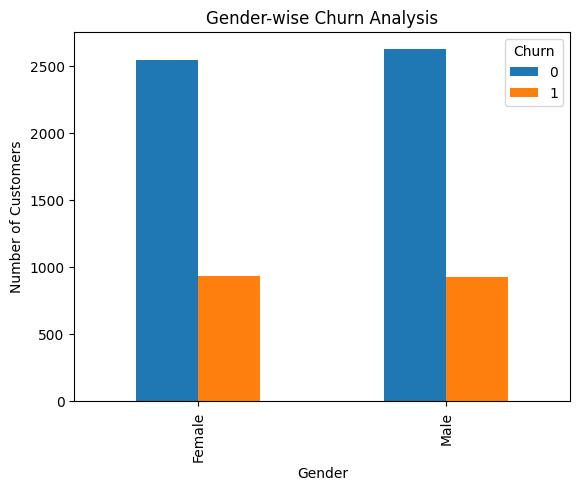

In [84]:
# Groups customers by gender and churn status, counts them, and displays a bar chart showing churn comparison for each gender.

gender_churn = df.groupby(['gender', 'Churn']).size().unstack()

print(gender_churn)

gender_churn.plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.title("Gender-wise Churn Analysis")
plt.show()

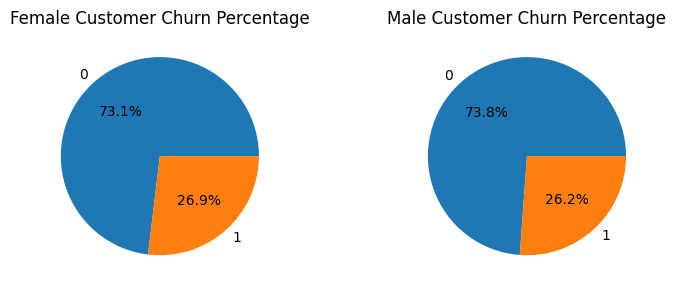

In [85]:
plt.figure(figsize=(8,3))

plt.subplot(1, 2, 1)
plt.pie(
    df[df['gender'] == 'Female']['Churn'].value_counts(),
    labels=df[df['gender'] == 'Female']['Churn'].value_counts().index,
    autopct='%1.1f%%'
)
plt.title("Female Customer Churn Percentage")

plt.subplot(1, 2, 2)
plt.pie(
    df[df['gender'] == 'Male']['Churn'].value_counts(),
    labels=df[df['gender'] == 'Male']['Churn'].value_counts().index,
    autopct='%1.1f%%'
)
plt.title("Male Customer Churn Percentage")
plt.tight_layout()
plt.show()


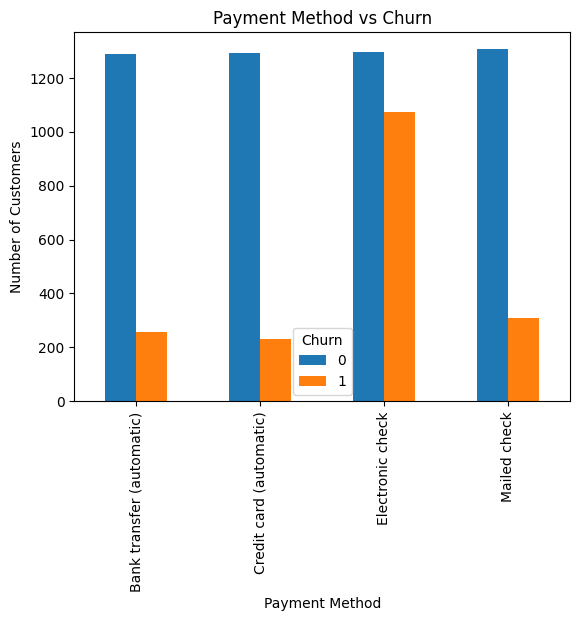

In [86]:
# Groups customers by payment method and churn status, counts them, and displays a bar chart comparing churn across different payment methods.

payment_churn = df.groupby(['PaymentMethod', 'Churn']).size().unstack()

payment_churn.plot(kind='bar')
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.title("Payment Method vs Churn")
plt.show()

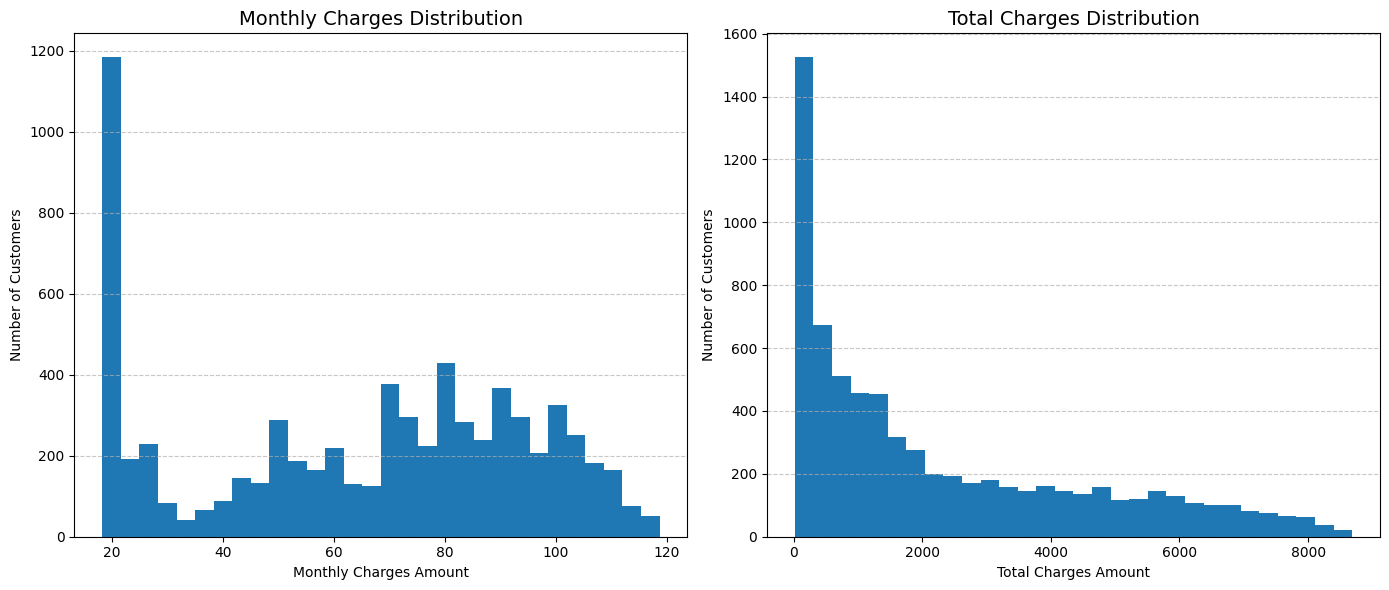

In [87]:
# Histograms showing the distribution of Monthly Charges and Total Charges for customers.
plt.figure(figsize=(14, 6))

# Subplot 1: Monthly Charges
plt.subplot(1, 2, 1)
plt.hist(df['MonthlyCharges'], bins=30)
plt.title("Monthly Charges Distribution", fontsize=14)
plt.xlabel("Monthly Charges Amount")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Total Charges
plt.subplot(1, 2, 2)
plt.hist(df['TotalCharges'].dropna(), bins=30)
plt.title("Total Charges Distribution", fontsize=14)
plt.xlabel("Total Charges Amount")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

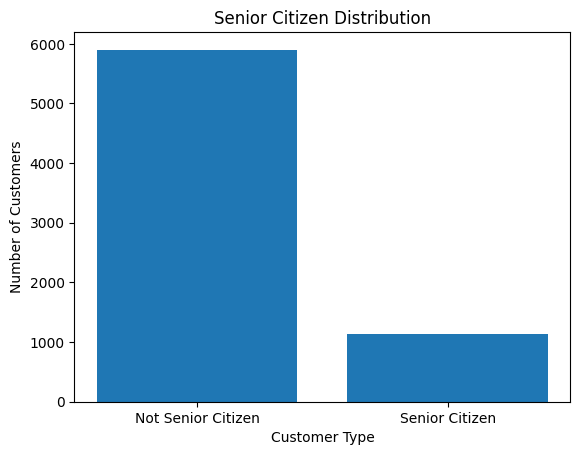

In [88]:
# Senior and non-senior customers

counts = df['SeniorCitizen'].value_counts()

# Plot
plt.figure()
plt.bar(['Not Senior Citizen', 'Senior Citizen'], counts.values)

plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.title("Senior Citizen Distribution")

plt.show()

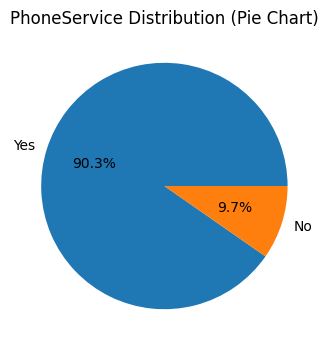

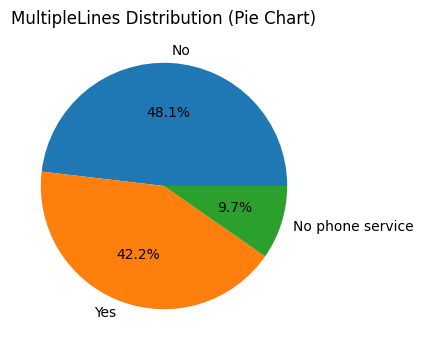

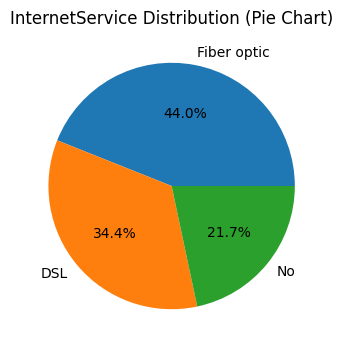

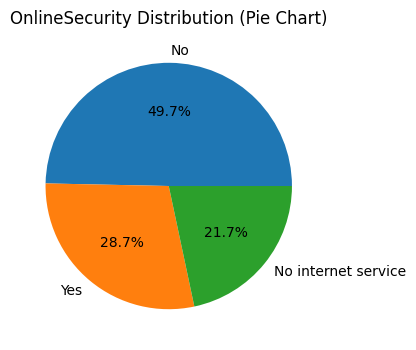

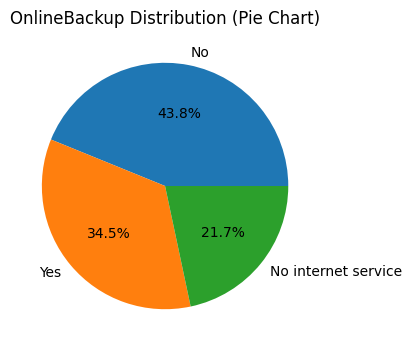

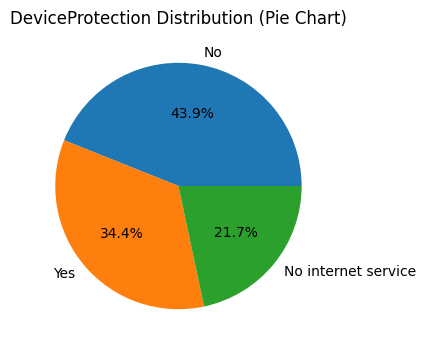

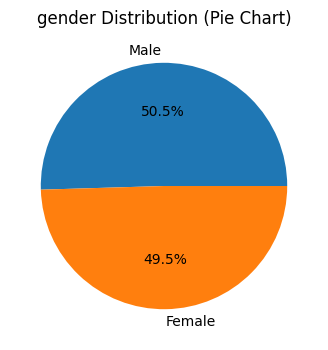

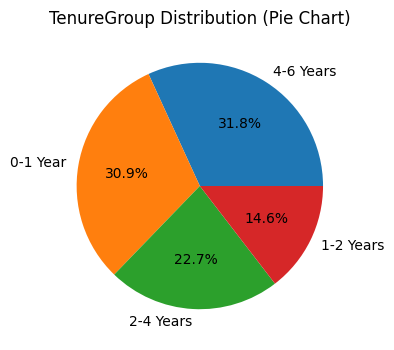

In [89]:


# Convert tenure into categories
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years']
)

# Categorical columns to plot
columns = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'gender',
    'TenureGroup'
]

# Loop through each column
for col in columns:
    counts = df[col].value_counts()


    # PIE CHART
    plt.figure(figsize=(6, 4))
    plt.pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%')
    plt.title(f"{col} Distribution (Pie Chart)")
    plt.show()
